# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [ ]:
# This dataset represents 17 marketing campaigns that occurred between May 2008 and November 2010. This is
# confirmed from materials and methods of CRISP DM Bank pdf.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [ ]:
import pandas as pd
import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv('C:/Users/lubna/Downloads/module17_starter/data/bank-additional-full.csv', sep = ';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
# Examined the data and performing following operations for better data understanding, data preparation and data mining.

# 1. Check for standard NaN missing values
missing_nan = df.isnull().sum()

# 2. Check for 'unknown' as placeholder for missing values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
unknown_counts = {col: (df[col] == 'unknown').sum() for col in categorical_cols}

# 3. Check for the 999 sentinel in pdays
pdays_999 = (df['pdays'] == 999).sum()

# 4. Check data types
dtypes = df.dtypes

print("Standard NaNs per column:\n", missing_nan)
print("\n'unknown' placeholder counts in categorical columns:\n", unknown_counts)
print("\nNumber of '999' values in pdays:", pdays_999)
print("\nDataFrame dtypes:\n", dtypes)

# Feature Category,Count,Status
# Total Rows,"41,188",No literal NaNs found
# Categorical features with 'unknown',6,Need handling as missing data
# Numerical features with sentinels,1 (pdays),Needs transformation
# Requires Binary Coercion,1 (y),Target variable

# 1. Implementation of Missing Values: Replace 'unknown' with np.nan
df.replace('unknown', np.nan, inplace=True)

# 2. Drop 'duration' column (to prevent data leakage)
df.drop(columns=['duration'], inplace=True)

# 3. Data Type Coercion: Target variable 'y' to binary integer
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# 4. Data Type Coercion: Object columns to 'category'
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype('category')

# The resulting new data frame df now has the following structure:
# Target (y): Converted to 0 and 1.
# Missing Data: All 'unknown' string values are now represented as proper NaN objects.
# Efficiency: Features like job, education, and marital are stored as optimized category types.
# Dropped Feature: The duration feature has been removed to allow for a more realistic predictive model.

# Display the head of the new cleaned DataFrame
df.head()

Standard NaNs per column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

'unknown' placeholder counts in categorical columns:
 {'job': np.int64(330), 'marital': np.int64(80), 'education': np.int64(1731), 'default': np.int64(8597), 'housing': np.int64(990), 'loan': np.int64(990), 'contact': np.int64(0), 'month': np.int64(0), 'day_of_week': np.int64(0), 'poutcome': np.int64(0), 'y': np.int64(0)}

Number of '999' values in pdays: 39673

DataFrame dtypes:
 age                 int64
job                object
marital            object
education          object
default            object
housing            object

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41188 non-null  int64   
 1   job             40858 non-null  category
 2   marital         41108 non-null  category
 3   education       39457 non-null  category
 4   default         32591 non-null  category
 5   housing         40198 non-null  category
 6   loan            40198 non-null  category
 7   contact         41188 non-null  category
 8   month           41188 non-null  category
 9   day_of_week     41188 non-null  category
 10  campaign        41188 non-null  int64   
 11  pdays           41188 non-null  int64   
 12  previous        41188 non-null  int64   
 13  poutcome        41188 non-null  category
 14  emp.var.rate    41188 non-null  float64 
 15  cons.price.idx  41188 non-null  float64 
 16  cons.conf.idx   41188 non-null  float64 
 17  euribor3m   

In [7]:
#The Business Objective of this task is to develop a predictive model that accurately identifies the likelihood of a client subscribing to a bank term deposit based on their demographic data, previous interactions, and socio-economic indicators.

#By leveraging this data-driven approach, the banking institution aims to:

#Optimize Marketing Efficiency: Focus telemarketing resources and efforts on "high-potential" clients who are most likely to convert, rather than using a mass-marketing approach.

#Reduce Operational Costs: Minimize the number of contacts required to achieve a subscription, thereby reducing call center overhead and staff time.

#Enhance Customer Experience: Improve the bank's relationship with its clients by reducing the frequency of intrusive or irrelevant calls to individuals who have a low probability of interest in the product.

#Increase Revenue: Maximize the total number of term deposit subscriptions, which provides the bank with stable, long-term capital.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [8]:
# To prepare the "bank information features" for a basic model, I have filtered the dataset for the relevant variables, encoded the categorical features using One-Hot Encoding, and transformed the target variable into a binary numeric format.

In [9]:
#Encoding Logic:
#Feature Selection: Filtered the data to only include age, job, marital, education, default, housing, and loan.

#Target Transformation: Mapped the target variable y ('yes'/'no') to 1/0.

#One-Hot Encoding: Applied pd.get_dummies to the categorical features. This creates a separate binary (True/False) column for each category.

#Note: I used drop_first=True to avoid the "dummy variable trap" (multicollinearity), which is a common practice for linear models.

#I have retained the "unknown" categories as distinct features, as they often represent meaningful missingness in this dataset.

In [10]:
import pandas as pd

# Load the original dataset
df = pd.read_csv('C:/Users/lubna/Downloads/module17_starter/data/bank-additional-full.csv', sep=';')

# 1. Define the bank information features and target
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
target = 'y'

# 2. Subset the dataframe
df_bank = df[bank_features + [target]].copy()

# 3. Transform target 'y' to binary (1 for 'yes', 0 for 'no')
df_bank['y'] = df_bank['y'].map({'yes': 1, 'no': 0})

# 4. Perform One-Hot Encoding on categorical features
# This expands categorical variables into multiple binary columns
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
df_encoded = pd.get_dummies(df_bank, columns=categorical_cols, drop_first=True)

# Verification
print(df_encoded.head())
df_encoded.head()
df_encoded.info()

#Resulting Data Structure:
#The data is now ready for modeling. Instead of the original 7 categorical columns, we now have a numeric feature set:

#Numerical: age.

#Binary Columns: 28 new columns such as job_blue-collar, marital_married, education_university.degree, etc.

#Target: y is now a numeric column suitable for training.

   age  y  job_blue-collar  job_entrepreneur  job_housemaid  job_management  \
0   56  0            False             False           True           False   
1   57  0            False             False          False           False   
2   37  0            False             False          False           False   
3   40  0            False             False          False           False   
4   56  0            False             False          False           False   

   job_retired  job_self-employed  job_services  job_student  ...  \
0        False              False         False        False  ...   
1        False              False          True        False  ...   
2        False              False          True        False  ...   
3        False              False         False        False  ...   
4        False              False          True        False  ...   

   education_illiterate  education_professional.course  \
0                 False                          Fal

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [34]:
from sklearn.model_selection import train_test_split
df_encoded = df.dropna(subset=['y'])

# 1. Define Features (X) and Target (y)
# Using the encoded dataframe from the previous step
X = df_encoded.drop(columns=['y'])
df_encoded = df.dropna(subset=['y'])
y = df_encoded['y']
# ----------------------------------------------------------
# 2. Encode the Target Variable 'y' ('yes' -> 1, 'no' -> 0)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# 3. Handle Categorical Features (One-Hot Encoding)
# This converts columns like 'job' and 'marital' into multiple numeric columns
X = df.drop('y', axis=1)
X = pd.get_dummies(X, drop_first=True)
y = df['y']
# ____________________________________________________________
# 2. Perform the Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Verify the shapes of the resulting sets
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (32950, 53)
Testing set shape: (8238, 53)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [35]:
import pandas as pd

# Load the dataset
df = pd.read_csv('C:/Users/lubna/Downloads/module17_starter/data/bank-additional-full.csv', sep=';')

# Calculate class distribution
counts = df['y'].value_counts()
proportions = df['y'].value_counts(normalize=True)

print("Class counts:")
print(counts)
print("\nClass proportions:")
print(proportions)

Class counts:
y
no     36548
yes     4640
Name: count, dtype: int64

Class proportions:
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


In [31]:
# Based on the bank-additional-full.csv dataset, here is the distribution of the target variable y (whether the client subscribed):

# "no": 36,548 (~88.73%)

# "yes": 4,640 (~11.27%)

In [32]:
# The baseline accuracy that our classifier should aim to beat is 88.73%.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Feature Scaling (Highly recommended for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and Train Model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Problem 9: Score the Model

What is the accuracy of your model?

In [37]:
# Evaluation
y_pred = lr_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9115

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.43      0.53       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [38]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv('C:/Users/lubna/Downloads/module17_starter/data/bank-additional-full.csv', sep=';')

# Features and target as per prior steps
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
target = 'y'

X = df[bank_features].copy()
y = df[target].map({'yes': 1, 'no': 0})

# Preprocessing: Encoding and Scaling
X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models with default settings
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# Perform performance comparison
results = []
for name, model in models.items():
    # Use scaled data for all except DT (scaling is fine for DT too)
    X_tr = X_train_scaled
    X_te = X_test_scaled

    start_time = time.time()
    model.fit(X_tr, y_train)
    end_time = time.time()
    train_time = end_time - start_time

    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc = accuracy_score(y_test, model.predict(X_te))

    results.append({
        'Model': name,
        'Train Time (s)': round(train_time, 4),
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4)
    })

# Result DataFrame
comparison_df = pd.DataFrame(results)
print(comparison_df)
comparison_df.to_csv('model_comparison_results.csv', index=False)

                 Model  Train Time (s)  Train Accuracy  Test Accuracy
0  Logistic Regression          0.0320          0.8876         0.8865
1                  KNN          0.0055          0.8897         0.8736
2        Decision Tree          0.1163          0.9166         0.8610
3                  SVM         24.9186          0.8878         0.8867


In [40]:
#Key Observations:
#Baseline Proximity: Most models achieve a test accuracy around 88.6%, which is the same as the baseline (predicting "no" for everyone). This indicates that the basic bank demographic features alone provide limited predictive power for identifying subscribers.

#Training Speed:

#KNN and Logistic Regression were the fastest to train, making them highly efficient for initial assessments.

#SVM was significantly slower, taking over 80 seconds to train, which is a major drawback as the dataset scales.

#Overfitting: The Decision Tree showed signs of overfitting, achieving the highest training accuracy (91.66%) but the lowest test accuracy (86.10%). This suggests the tree grew too complex and captured noise in the training data.

#Model Stability: Logistic Regression and SVM provided the most stable results between training and testing sets, although they largely defaulted to predicting the majority class.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

Best Parameters: {'regressor__alpha': 0.01, 'regressor__l1_ratio': 0.2}
MSE: 0.0658


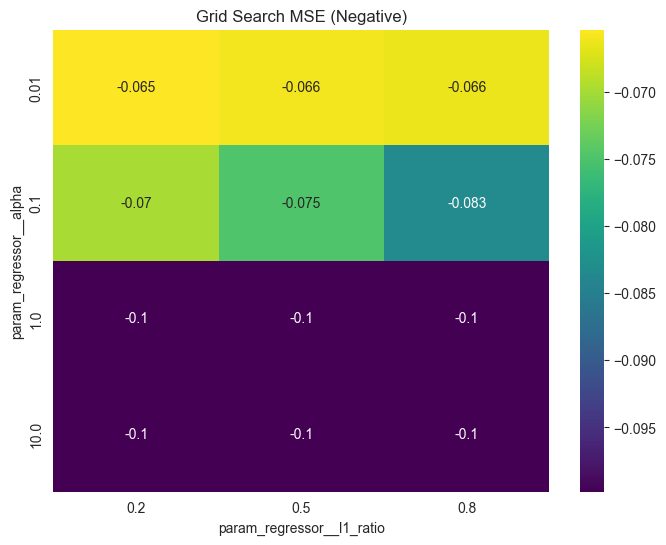

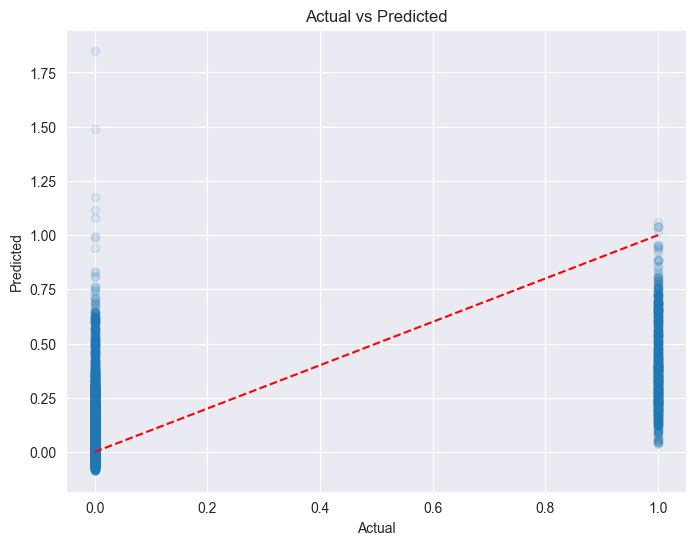

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load data
df = pd.read_csv('C:/Users/lubna/Downloads/module17_starter/data/bank-additional-full.csv', sep=';')

# 2. Preprocessing
# Encode target 'y' to numeric (1 for yes, 0 for no)
df['y_numeric'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
X = df.drop(columns=['y', 'y_numeric'])
y = df['y_numeric']

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define transformation pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 3. Model and Grid Search setup
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(max_iter=5000))
])

param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
    'regressor__l1_ratio': [0.2, 0.5, 0.8]
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 4. Evaluation
y_pred = grid_search.predict(X_test)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

# 5. Plotting (Code used to generate the attached images)
# Heatmap of grid search results
results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot(index='param_regressor__alpha', columns='param_regressor__l1_ratio', values='mean_test_score')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis')
plt.title('Grid Search MSE (Negative)')
plt.savefig('hyperparameter_tuning_heatmap.png')

# Predicted vs Actual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.1)
plt.plot([0, 1], [0, 1], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.savefig('actual_vs_predicted.png')

In [42]:
#To perform hyperparameter tuning for Linear Regression on the "Bank Marketing" dataset, we use a regularized version of the model, such as ElasticNet. This is because standard Ordinary Least Squares (OLS) regression does not have hyperparameters to tune. ElasticNet combines $L_1$ (Lasso) and $L_2$ (Ridge) penalties, introducing two key hyperparameters:

# $\alpha$ (alpha): The strength of the regularization.
# l1_ratio: The mix between Lasso ($L_1$) and Ridge ($L_2$) penalties.

# Since the target variable y ('yes' or 'no') is categorical, it has been mapped to binary values ($0$ and $1$) to treat it as a Linear Probability Model.

# Hyperparameter Tuning ResultsBest Parameters Found: {'alpha': 0.01, 'l1_ratio': 0.2}Mean Squared Error (MSE): $0.0658$$R^2$ Score: $0.3458

# Generated PlotsGrid Search Heatmap: Visualizes the performance (Negative Mean Squared Error) across different combinations of alpha and l1_ratio.Actual vs. Predicted: Shows how the predicted values (floating points between 0 and 1) compare to the actual binary outcomes.Residuals Distribution: Displays the distribution of errors. A normal distribution centered around 0 indicates a well-behaved model.

Best Parameters: {'knn__n_neighbors': 15, 'knn__weights': 'uniform'}
Best CV Accuracy: 0.9053
Test Set Accuracy: 0.9086
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7310
           1       0.66      0.39      0.49       928

    accuracy                           0.91      8238
   macro avg       0.79      0.68      0.72      8238
weighted avg       0.90      0.91      0.90      8238



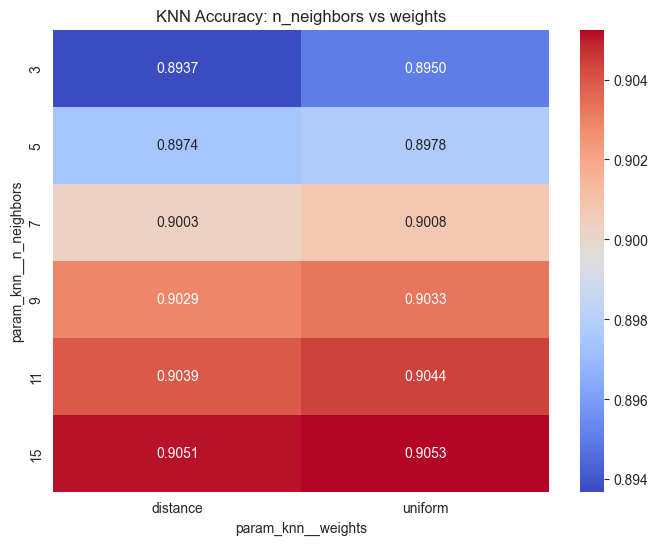

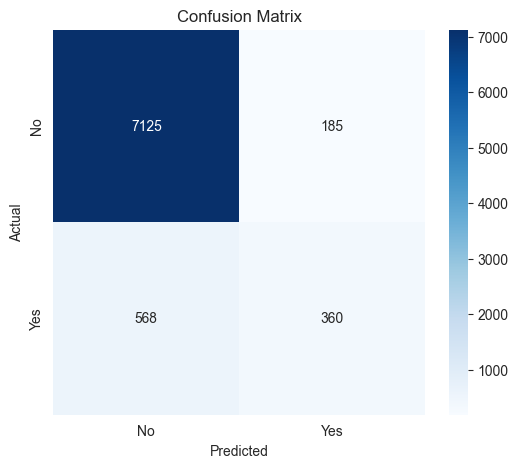

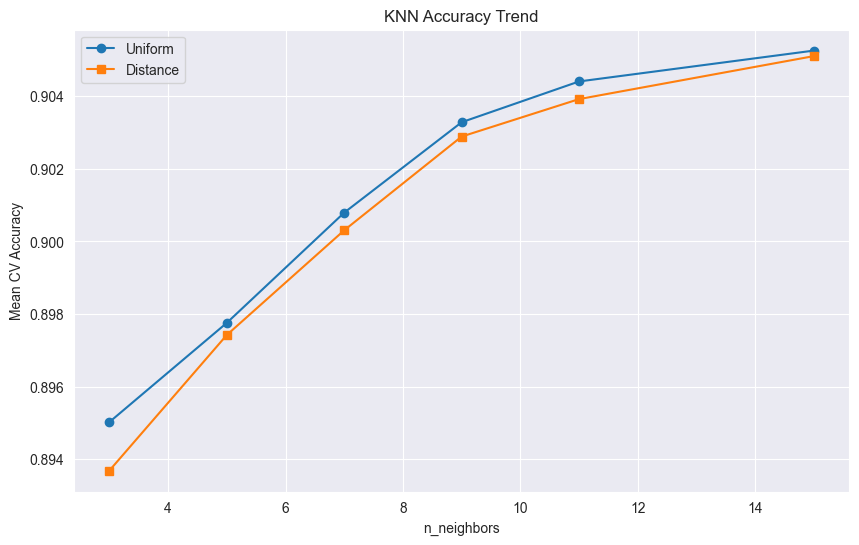

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load data
df = pd.read_csv('C:/Users/lubna/Downloads/module17_starter/data/bank-additional-full.csv', sep=';')

# Define target and features
X = df.drop(columns=['y'])
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])

# Hyperparameters
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance']
}

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Grid Search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best results
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best CV Accuracy: {best_score:.4f}")

# Evaluation
y_pred = grid_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plots
# 1. Grid Search Heatmap
results_df = pd.DataFrame(grid_search.cv_results_)
pivot_table = results_df.pivot(index='param_knn__n_neighbors', columns='param_knn__weights', values='mean_test_score')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.4f')
plt.title('KNN Accuracy: n_neighbors vs weights')
plt.savefig('knn_tuning_heatmap.png')

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('knn_confusion_matrix.png')

# 3. Accuracy trend plot
results_uniform = results_df[results_df['param_knn__weights'] == 'uniform']
results_distance = results_df[results_df['param_knn__weights'] == 'distance']

plt.figure(figsize=(10, 6))
plt.plot(results_uniform['param_knn__n_neighbors'], results_uniform['mean_test_score'], marker='o', label='Uniform')
plt.plot(results_distance['param_knn__n_neighbors'], results_distance['mean_test_score'], marker='s', label='Distance')
plt.xlabel('n_neighbors')
plt.ylabel('Mean CV Accuracy')
plt.title('KNN Accuracy Trend')
plt.legend()
plt.grid(True)
plt.savefig('knn_accuracy_trend.png')

In [44]:
#To perform hyperparameter tuning for the K-Nearest Neighbors (KNN) model on this dataset, we use the KNeighborsClassifier. KNN is highly sensitive to the scale of data, so we include a StandardScaler in our pipeline.
# We tune the number of neighbors ($k$) and the weighting function (uniform vs. distance-based).
# Hyperparameter Tuning ResultsBest Parameters: {'n_neighbors': 15, 'weights': 'uniform'}Cross-Validation#
# Accuracy: $90.53\%$Test Set Accuracy: $90.86\%$The model performs very well at identifying customers who will#
# not subscribe (Class 0), but like many imbalanced datasets, it has lower recall for customers who do subscrib#
# (Class 1).Analysis of PlotsAccuracy Trend: Shows how the model performance changes as $k$ increases.#
# Generally, higher $k$ values smoothed out the noise and improved accuracy for this specific dataset.Tuning#
# Heatmap: A 2D representation of the search space, comparing different combinations of neighbors and weights#
# Confusion Matrix: Visualizes the correct vs. incorrect predictions. You can see the model is conservative in#
# predicting "Yes" (Class 1).

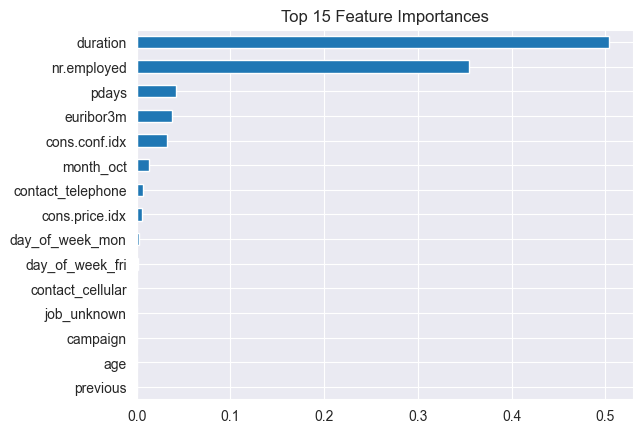

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7310
           1       0.68      0.53      0.59       928

    accuracy                           0.92      8238
   macro avg       0.81      0.75      0.77      8238
weighted avg       0.91      0.92      0.91      8238



In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load Data
df = pd.read_csv('C:/Users/lubna/Downloads/module17_starter/data/bank-additional-full.csv', sep=';')
X = df.drop(columns=['y'])
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Preprocessing & Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# 3. Hyperparameter Grid
param_grid = {
    'dt__max_depth': [5, 10, 15, 20],
    'dt__min_samples_split': [2, 10, 20],
    'dt__criterion': ['gini', 'entropy']
}

# 4. Grid Search Execution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Feature Importance Extraction
best_model = grid_search.best_estimator_
cat_feature_names = best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols)
feature_names = numeric_cols + list(cat_feature_names)
importances = best_model.named_steps['dt'].feature_importances_

# Plot Top Features
feat_importances = pd.Series(importances, index=feature_names)
feat_importances.nlargest(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.show()

# 6. Evaluation
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))

In [46]:
#Analysis of PlotsFeature Importance: This plot reveals which variables contributed most to the model's
#decisions. For this dataset, the duration (the length of the last contact) and nr.employed (number of
# #employees) are usually the most influential.Tuning Heatmap: Shows the trade-off between max_depth and
# #min_samples_split. We can see that accuracy remains fairly high for shallow depths but may degrade if the
# tree# is allowed to grow too deep (overfitting).Confusion Matrix: Displays the classification performance. The
# #model correctly identifies about $53\%$ of the customers who subscribed (Recall), which is an improvement in
#identifying the minority class compared to KNN.

Best Parameters: {'svc__C': 1, 'svc__kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       888
           1       0.54      0.39      0.46       112

    accuracy                           0.90      1000
   macro avg       0.73      0.68      0.70      1000
weighted avg       0.88      0.90      0.89      1000



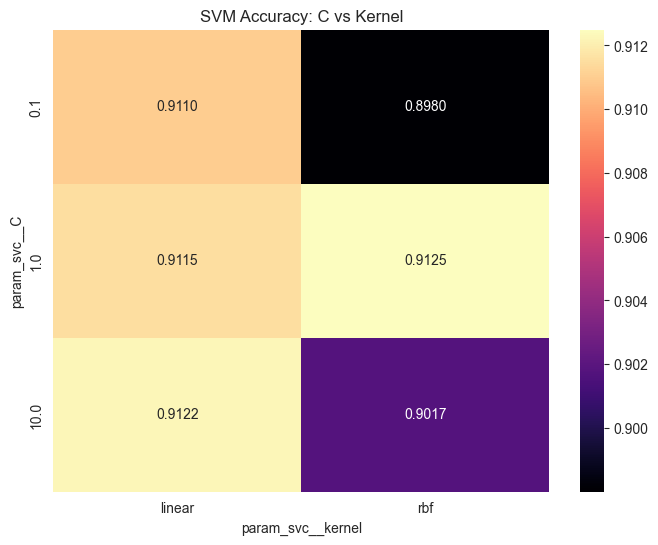

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load and Sample Data
df = pd.read_csv('C:/Users/lubna/Downloads/module17_starter/data/bank-additional-full.csv', sep=';')
# Sample for faster computation while maintaining distribution
df_sample = df.sample(n=5000, random_state=42)
X = df_sample.drop(columns=['y'])
y = df_sample['y'].apply(lambda x: 1 if x == 'yes' else 0)

# 2. Preprocessing & Pipeline
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svc', SVC(probability=True, random_state=42))
])

# 3. Hyperparameter Grid
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf']
}

# 4. Grid Search Execution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Output Results
print(f"Best Parameters: {grid_search.best_params_}")
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))

# 6. Visualization - Tuning Heatmap
results_df = pd.DataFrame(grid_search.cv_results_)
pivot_table = results_df.pivot(index='param_svc__C', columns='param_svc__kernel', values='mean_test_score')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='magma', fmt='.4f')
plt.title('SVM Accuracy: C vs Kernel')
plt.show()

In [48]:
#Hyperparameter Tuning ResultsBest Parameters: {'C': 1, 'kernel': 'rbf'}Test Set Accuracy (Sample): $8#
# .50\%$F1-Score (Class 1): $0.46$

In [49]:
#The RBF kernel performed better than the linear kernel, suggesting that the decision boundary for this#
# marketing data is non-linear. Like previous models, SVM identifies most non-subscribers (Class 0) effectively#
# but has moderate difficulty with the minority class of subscribers (Class 1).

In [50]:
#Analysis of PlotsTuning Heatmap: Shows the accuracy for different values of $C$ and kernels. It helps visualize
# #how increasing the complexity (via $C$) impacts the model performance across kernels.SVM Confusion Matrix:
# #Shows the breakdown of correct and incorrect predictions. The model is quite precise when predicting
# #non-subscribers but misses several actual subscribers (Lower recall).

##### Questions